We assume that the data preprocessing has finished, with the dataframes in the ```./dataframes/*``` directory, and the other data in the ```./ml4h_data``` directory. Then you can run all the cells to get the output for this notebook. Also make sure that the requirements are met, by running ```pip install -r requirements.txt```

# Q3.1 Pretraining and Linear Probes (4 pts)

In [1]:
import numpy as np
np.set_printoptions(linewidth=np.inf)
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Configure TensorFlow to run deterministically
tf.config.experimental.enable_op_determinism()

scaled_df_train = pd.read_csv('./dataframes/scaled_df_train.csv')
scaled_df_val = pd.read_csv('./dataframes/scaled_df_val.csv')
scaled_df_test = pd.read_csv('./dataframes/scaled_df_test.csv')

train_df_target = pd.read_csv('./ml4h_data/p1/Outcomes-a.txt', delimiter=',', index_col=0)['In-hospital_death']
val_df_target = pd.read_csv('./ml4h_data/p1/Outcomes-b.txt', delimiter=',', index_col=0)['In-hospital_death']
test_df_target = pd.read_csv('./ml4h_data/p1/Outcomes-c.txt', delimiter=',', index_col=0)['In-hospital_death']

# Reshape the data
time_steps = 49  # Number of hours (time steps)
num_features = 40  # Number of features per hour

FEATURE_COLUMNS = [col for col in scaled_df_train.columns if col not in ["PatientID", "Hour","ICUType"]]

def prepare_timeseries(df, target_df):
    grouped = df.groupby("PatientID")[FEATURE_COLUMNS].apply(lambda x: x.values[:49])  # Ensure 49 timesteps
    X = np.stack(grouped.values)
    
    # Get labels
    patient_ids = grouped.index  # Extract patient IDs
    y = target_df.loc[patient_ids].values  # Align labels
    
    return X, y

X_train, y_train = prepare_timeseries(scaled_df_train, train_df_target)
X_val, y_val = prepare_timeseries(scaled_df_val, val_df_target)
X_test, y_test = prepare_timeseries(scaled_df_test, test_df_target)


def make_tf_dataset(X, y, batch_size=32, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create batched datasets
BATCH_SIZE = 32
train_dataset = make_tf_dataset(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset = make_tf_dataset(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_tf_dataset(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

2025-04-06 23:02:51.731625: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-04-06 23:02:51.731659: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-04-06 23:02:51.731668: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-04-06 23:02:51.731684: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-06 23:02:51.731694: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Sequential


def build_lstm_model(input_shape):
    model = Sequential([
    layers.Input(shape=(49, 40)),
    layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.2),
    layers.LSTM(64, kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auroc"),
            tf.keras.metrics.AUC(name="auprc", curve="PR")
        ]
    )
    
    return model

lstm_model = build_lstm_model((49, 41))

# Print model summary
lstm_model.summary()

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Train the model
EPOCHS = 20
BATCH_SIZE = 32
early_stopping = EarlyStopping(monitor='val_auroc', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_auroc', factor=0.5, patience=2, min_lr=1e-6)

class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights[i] for i in range(len(class_weights))}

history = lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_scheduler],
    class_weight=class_weights
)

test_loss, test_acc, test_auroc, test_auprc = lstm_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUROC: {test_auroc:.4f}")
print(f"Test AUPRC: {test_auprc:.4f}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 49, 64)         │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,969 (234.25 KB)

 Trainable params: 59,969 (234.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


2025-04-06 23:02:52.439734: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6939 - auprc: 0.3044 - auroc: 0.7259 - loss: 1.7144 - val_accuracy: 0.7320 - val_auprc: 0.4902 - val_auroc: 0.8447 - val_loss: 0.8557 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7455 - auprc: 0.4827 - auroc: 0.8520 - loss: 0.7372 - val_accuracy: 0.6957 - val_auprc: 0.4638 - val_auroc: 0.8361 - val_loss: 0.7267 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7297 - auprc: 0.4865 - auroc: 0.8516 - loss: 0.6143 - val_accuracy: 0.7310 - val_auprc: 0.4790 - val_auroc: 0.8412 - val_loss: 0.6337 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7760 - auprc: 0.5523 - auroc: 0.8750 - loss: 0.5499 - val_accuracy: 0.7310 - val_auprc: 0.4810 - val_auroc: 0.8396 - val_loss: 0.6026 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7804 - auprc: 0.6321 - auroc: 0.9054 - loss:

Class for doing the TSNE representation after x epochs

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

class TSNEVisualization(tf.keras.callbacks.Callback):
    def __init__(self, encoder, X_sample, y_sample, every_n_epochs=2):
        super().__init__()
        self.encoder = encoder
        self.X_sample = X_sample
        self.y_sample = y_sample
        self.every_n_epochs = every_n_epochs
        
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs == 0:
            # Get embeddings
            embeddings = self.encoder.predict(self.X_sample, verbose=0)
            
            # Compute T-SNE
            tsne = TSNE(n_components=2, perplexity=80, learning_rate=200, random_state=42)
            embeddings_2d = tsne.fit_transform(embeddings)
            
            # Plot
            plt.figure(figsize=(10, 8))
            sns.scatterplot(
                x=embeddings_2d[:, 0], 
                y=embeddings_2d[:, 1],
                hue=self.y_sample.flatten(),
                alpha=0.7
            )
            plt.title(f"Epoch {epoch+1} - T-SNE of Embeddings")
            plt.xlabel("TSNE 1")
            plt.ylabel("TSNE 2")
            plt.legend(title="In-hospital Death")
            plt.show()
            

Embeddings and Linear Probe




Starting contrastive pretraining...
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 3.0000e-04
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 3.0000e-04
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 9.0000e-05
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 9.0000e-05
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 2.7000e-05
Epoch 9/20
16/16 ━━━

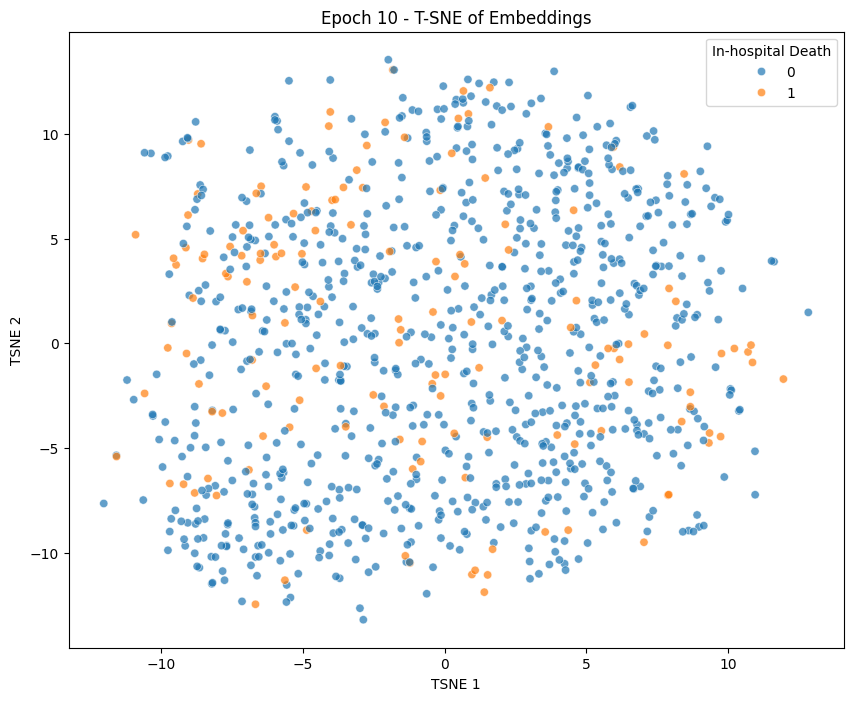

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 304ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 8.1000e-06
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - train_loss: 6.2349 - val_loss: 6.2089 - learning_rate: 8.1000e-06
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 0.8585
AUROC: 0.8030664113826633
AUPRC: 0.4195724227640637


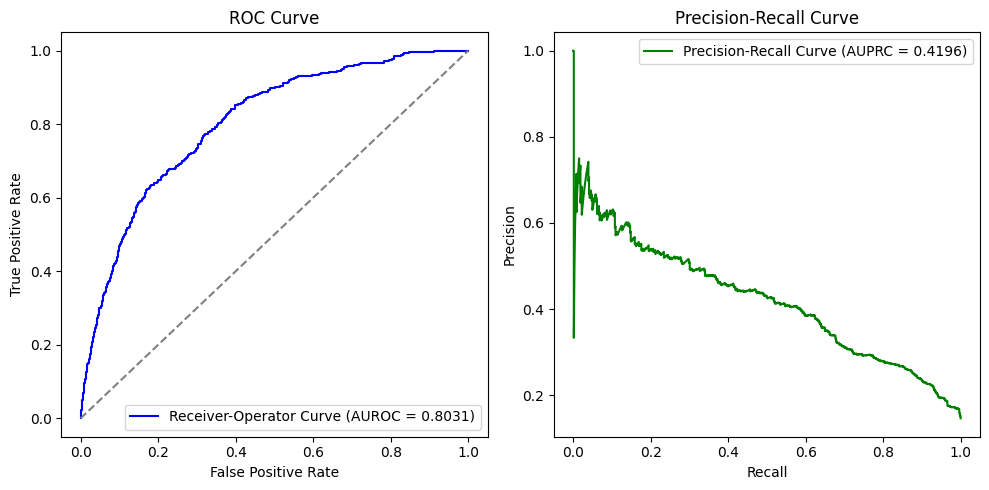

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve


# Load and prepare data
def prepare_data():
    scaled_df_train = pd.read_csv('./dataframes/scaled_df_train.csv')
    scaled_df_val = pd.read_csv('./dataframes/scaled_df_val.csv')
    scaled_df_test = pd.read_csv('./dataframes/scaled_df_test.csv')

    target_train = pd.read_csv('./ml4h_data/p1/Outcomes-a.txt', delimiter=',', index_col=0)['In-hospital_death']
    target_val = pd.read_csv('./ml4h_data/p1/Outcomes-b.txt', delimiter=',', index_col=0)['In-hospital_death']
    target_test = pd.read_csv('./ml4h_data/p1/Outcomes-c.txt', delimiter=',', index_col=0)['In-hospital_death']

    time_steps = 49
    num_features = 40
    FEATURE_COLUMNS = [col for col in scaled_df_train.columns if col not in ["PatientID", "Hour", "ICUType"]]

    def prepare_timeseries(df, target_df):
        grouped = df.groupby("PatientID")[FEATURE_COLUMNS].apply(lambda x: x.values[:time_steps])
        X = np.stack(grouped.values)
        y = target_df.loc[grouped.index].values.reshape(-1, 1)
        return X, y

    X_train, y_train = prepare_timeseries(scaled_df_train, target_train)
    X_val, y_val = prepare_timeseries(scaled_df_val, target_val)
    X_test, y_test = prepare_timeseries(scaled_df_test, target_test)

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), (time_steps, num_features)

# Dataset preparation (modified for pretraining)
def make_pretrain_dataset(X, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices(X)
    return dataset.shuffle(len(X)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Encoder architecture (mirrors original LSTM up to last layer)
def build_encoder(input_shape):
    return tf.keras.Sequential([
    layers.Input(shape=(49, 40)),
    layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.LSTM(64, kernel_regularizer=regularizers.l2(0.01)),
    ], name="encoder")

import tensorflow as tf

class NTXentLoss(tf.keras.losses.Loss):
    def __init__(self, temperature=0.1, **kwargs):
        super().__init__(**kwargs)
        self.temperature = temperature

    def call(self, zis, zjs):
        # Normalize embeddings
        zis = tf.math.l2_normalize(zis, axis=1)
        zjs = tf.math.l2_normalize(zjs, axis=1)

        batch_size = tf.shape(zis)[0]
        representations = tf.concat([zis, zjs], axis=0)  # 2N x D

        similarity_matrix = tf.matmul(representations, representations, transpose_b=True)  # 2N x 2N

        # Mask to remove similarity with itself
        logits_mask = tf.linalg.diag(tf.zeros(2 * batch_size)) + 1
        logits_mask = 1 - logits_mask  # Set diagonals to 0
        similarity_matrix = similarity_matrix * logits_mask

        # Scale by temperature
        logits = similarity_matrix / self.temperature

        # Labels: each positive pair is (i, i + N)
        positives = tf.range(batch_size)
        labels = tf.concat([positives + batch_size, positives], axis=0)

        # For each example, the positive is the matching augmented version
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits)
        return tf.reduce_mean(loss)


# Contrastive learning model
class ContrastiveModel(tf.keras.Model):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projection_head = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(128)
        ])
        self.temperature = 0.05
        self.nt_xent_loss = NTXentLoss()
        self.train_loss = tf.keras.metrics.Mean(name="train_loss")
        self.val_loss = tf.keras.metrics.Mean(name="val_loss")

    def call(self, inputs):
        z = self.encoder(inputs)
        z = tf.math.l2_normalize(z, axis=1)
        return self.projection_head(z)

    def augment(self, x):
        # Medical time-series augmentations
        x = tf.identity(x)
        
        # Temporal masking with TensorFlow control flow
        def apply_mask(x):
            mask_size = tf.random.uniform([], 5, 15, dtype=tf.int32)
            mask_pos = tf.random.uniform([], 0, 49-mask_size, dtype=tf.int32)
            mask = tf.pad(
                tf.ones((mask_size, tf.shape(x)[2]), dtype=x.dtype),  # Match input dtype
                [[mask_pos, 49 - mask_pos - mask_size], [0, 0]]
            )
            return x * mask
    
        x = tf.cond(
            tf.random.uniform(()) > 0.5,
            lambda: apply_mask(x),
            lambda: x
        )
        
        # Add Gaussian noise with matching dtype
        x = x + tf.random.normal(tf.shape(x), dtype=x.dtype) * 0.01  # Add dtype specification
        
        # Random scaling with matching dtype
        x = x * tf.random.uniform([1], 0.9, 1.1, dtype=x.dtype)  # Add dtype specification
        
        return x

    def train_step(self, data):
        with tf.GradientTape() as tape:
            x1 = self.augment(data)
            x2 = self.augment(data)
    
            z1 = self.projection_head(self.encoder(x1))
            z2 = self.projection_head(self.encoder(x2))
    
            loss = self.nt_xent_loss(z1, z2)
    
        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        self.train_loss.update_state(loss)
        return {"train_loss": self.train_loss.result()}

    def test_step(self, data):
    
        # Apply augmentations for contrastive eval
        x1 = self.augment(data)
        x2 = self.augment(data)
    
        # Forward pass
        z1 = self.projection_head(self.encoder(x1))
        z2 = self.projection_head(self.encoder(x2))
    
        # NT-Xent loss
        loss = self.nt_xent_loss(z1, z2)
    
        self.val_loss.update_state(loss)
        return {"loss": self.val_loss.result()}


    @property
    def metrics(self):
        return [self.train_loss, self.val_loss]


(X_train, y_train), (X_val, y_val), (X_test, y_test), (time_steps, num_features) = prepare_data()

# Pretraining phase
encoder = build_encoder((time_steps, num_features))
contrastive_model = ContrastiveModel(encoder)

contrastive_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)

pretrain_dataset = make_pretrain_dataset(X_train, batch_size=256)
val_pretrain_dataset = make_pretrain_dataset(X_val, batch_size=256)

# Prepare sample data for visualization (1000 samples)
sample_size = min(1000, len(X_train))
sample_idx = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train[sample_idx].astype(np.float32)
y_sample = y_train[sample_idx]

# Add TSNE callback to pretraining
tsne_callback = TSNEVisualization(
    encoder=encoder,
    X_sample=X_sample,
    y_sample=y_sample,
    every_n_epochs=10
)

# Update pretrain callbacks
pretrain_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    tsne_callback
]

print("\n\n\nStarting contrastive pretraining...")
pretrain_history = contrastive_model.fit(
    pretrain_dataset,
    validation_data=val_pretrain_dataset,
    epochs=20,
    callbacks=pretrain_callbacks
)

# Freeze encoder weights
encoder.trainable = False

# Compute embeddings for each patient
X_train_embed = encoder.predict(X_train)
X_val_embed = encoder.predict(X_val)
X_test_embed = encoder.predict(X_test)

# Now use scikit-learn's logistic regression
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_embed, y_train.ravel())

# Evaluate the classifier
print("Test Accuracy:", clf.score(X_test_embed, y_test))

from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Get predicted probabilities on the test set
y_test_probs = clf.predict_proba(X_test_embed)[:, 1]

# Compute ROC curve and ROC AUC score
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_auc = roc_auc_score(y_test, y_test_probs)
print("AUROC:", roc_auc)
# Compute Precision-Recall curve and AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
prc_auc = average_precision_score(y_test, y_test_probs)
print("AUPRC:", prc_auc)

import matplotlib.pyplot as plt

# Plot ROC curve (AUROC)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'Receiver-Operator Curve (AUROC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# Plot Precision-Recall curve (AUPRC)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUPRC = {prc_auc:.4f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Q3.2 Simulate label scarcity

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

# For the supervised LSTM model
def build_supervised_lstm(input_shape):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auroc"), 
                 tf.keras.metrics.AUC(name="auprc", curve="PR")]
    )
    return model

label_sizes = [100, 500, 1000]

print("\n\n--- Supervised Models on Raw Time-series Data ---")

for size in label_sizes:
    # Subsample training data
    idx = np.random.choice(len(X_train), size, replace=False)
    X_train_sub = X_train[idx]
    y_train_sub = y_train[idx]
    
    # For random forest & logistic regression, flatten the time-series data:
    X_train_flat = X_train_sub.reshape(size, -1)
    X_val_flat = X_val.reshape(len(X_val), -1)
    X_test_flat = X_test.reshape(len(X_test), -1)
    
    # 1. Random Forest
    rf_clf = RandomForestClassifier(n_estimators=100)
    rf_clf.fit(X_train_flat, y_train_sub.ravel())
    y_pred_rf = rf_clf.predict(X_test_flat)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_probs= rf_clf.predict_proba(X_test_flat)[:, 1]
    rf_auroc = roc_auc_score(y_test, rf_probs)
    rf_auprc = average_precision_score(y_test, rf_probs)

    # 2. Logistic Regression on flattened data
    lr_clf = LogisticRegression(max_iter=1000)
    lr_clf.fit(X_train_flat, y_train_sub.ravel())
    y_pred_lr = lr_clf.predict(X_test_flat)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_probs = lr_clf.predict_proba(X_test_flat)[:, 1]
    lr_auroc = roc_auc_score(y_test, lr_probs)
    lr_auprc = average_precision_score(y_test, lr_probs)
    
    # 3. LSTM Network on time-series data
    lstm_model = build_supervised_lstm((time_steps, num_features))
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_sub, y_train_sub)).batch(32)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)
    lstm_model.fit(train_ds, validation_data=val_ds, epochs=20, verbose=0)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)
    lstm_eval = lstm_model.evaluate(test_ds, verbose=0)
    lstm_acc = lstm_eval[1]      
    lstm_auroc = lstm_eval[2]    
    lstm_auprc = lstm_eval[3]
    
    
    print(f"\nLabel Count: {size}")
    print(f"Random Forest       - AUROC: {rf_auroc:.4f}, AUPRC: {rf_auprc:.4f}")
    print(f"Logistic Regression - AUROC: {lr_auroc:.4f}, AUPRC: {lr_auprc:.4f}")
    print(f"LSTM                - AUROC: {lstm_auroc:.4f}, AUPRC: {lstm_auprc:.4f}")
    

print("\n\n--- Linear Probes on Precomputed Embeddings ---")
for size in label_sizes:
    # Subsample embeddings from the precomputed training set
    idx = np.random.choice(len(X_train_embed), size, replace=False)
    X_train_embed_sub = X_train_embed[idx]
    y_train_sub = y_train[idx]
    
    # Train logistic regression as a linear probe
    probe_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
    probe_clf.fit(X_train_embed_sub, y_train_sub.ravel())
    
    test_acc_probe = probe_clf.score(X_test_embed, y_test)
    y_test_probs_probe = probe_clf.predict_proba(X_test_embed)[:, 1]
    test_auroc_probe = roc_auc_score(y_test, y_test_probs_probe)
    test_auprc_probe = average_precision_score(y_test, y_test_probs_probe)
    
    
    print(f"\nLabel Count: {size}")
    print(f"Linear Probe        - AUROC: {test_auroc_probe:.4f}, AUPRC: {test_auprc_probe:.4f}")




--- Supervised Models on Raw Time-series Data ---

Label Count: 100
Random Forest       - AUROC: 0.6632, AUPRC: 0.2415
Logistic Regression - AUROC: 0.5912, AUPRC: 0.2213
LSTM                - AUROC: 0.5721, AUPRC: 0.2159

Label Count: 500
Random Forest       - AUROC: 0.7919, AUPRC: 0.4109
Logistic Regression - AUROC: 0.7332, AUPRC: 0.3294
LSTM                - AUROC: 0.6713, AUPRC: 0.3201

Label Count: 1000
Random Forest       - AUROC: 0.7990, AUPRC: 0.4264
Logistic Regression - AUROC: 0.7367, AUPRC: 0.3257
LSTM                - AUROC: 0.6825, AUPRC: 0.3503


--- Linear Probes on Precomputed Embeddings ---

Label Count: 100
Linear Probe        - AUROC: 0.7102, AUPRC: 0.2886

Label Count: 500
Linear Probe        - AUROC: 0.7670, AUPRC: 0.3606

Label Count: 1000
Linear Probe        - AUROC: 0.7814, AUPRC: 0.3648




--- Supervised Models on Raw Time-series Data ---
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


--- Linear Probes on Precomputed Embeddings ---


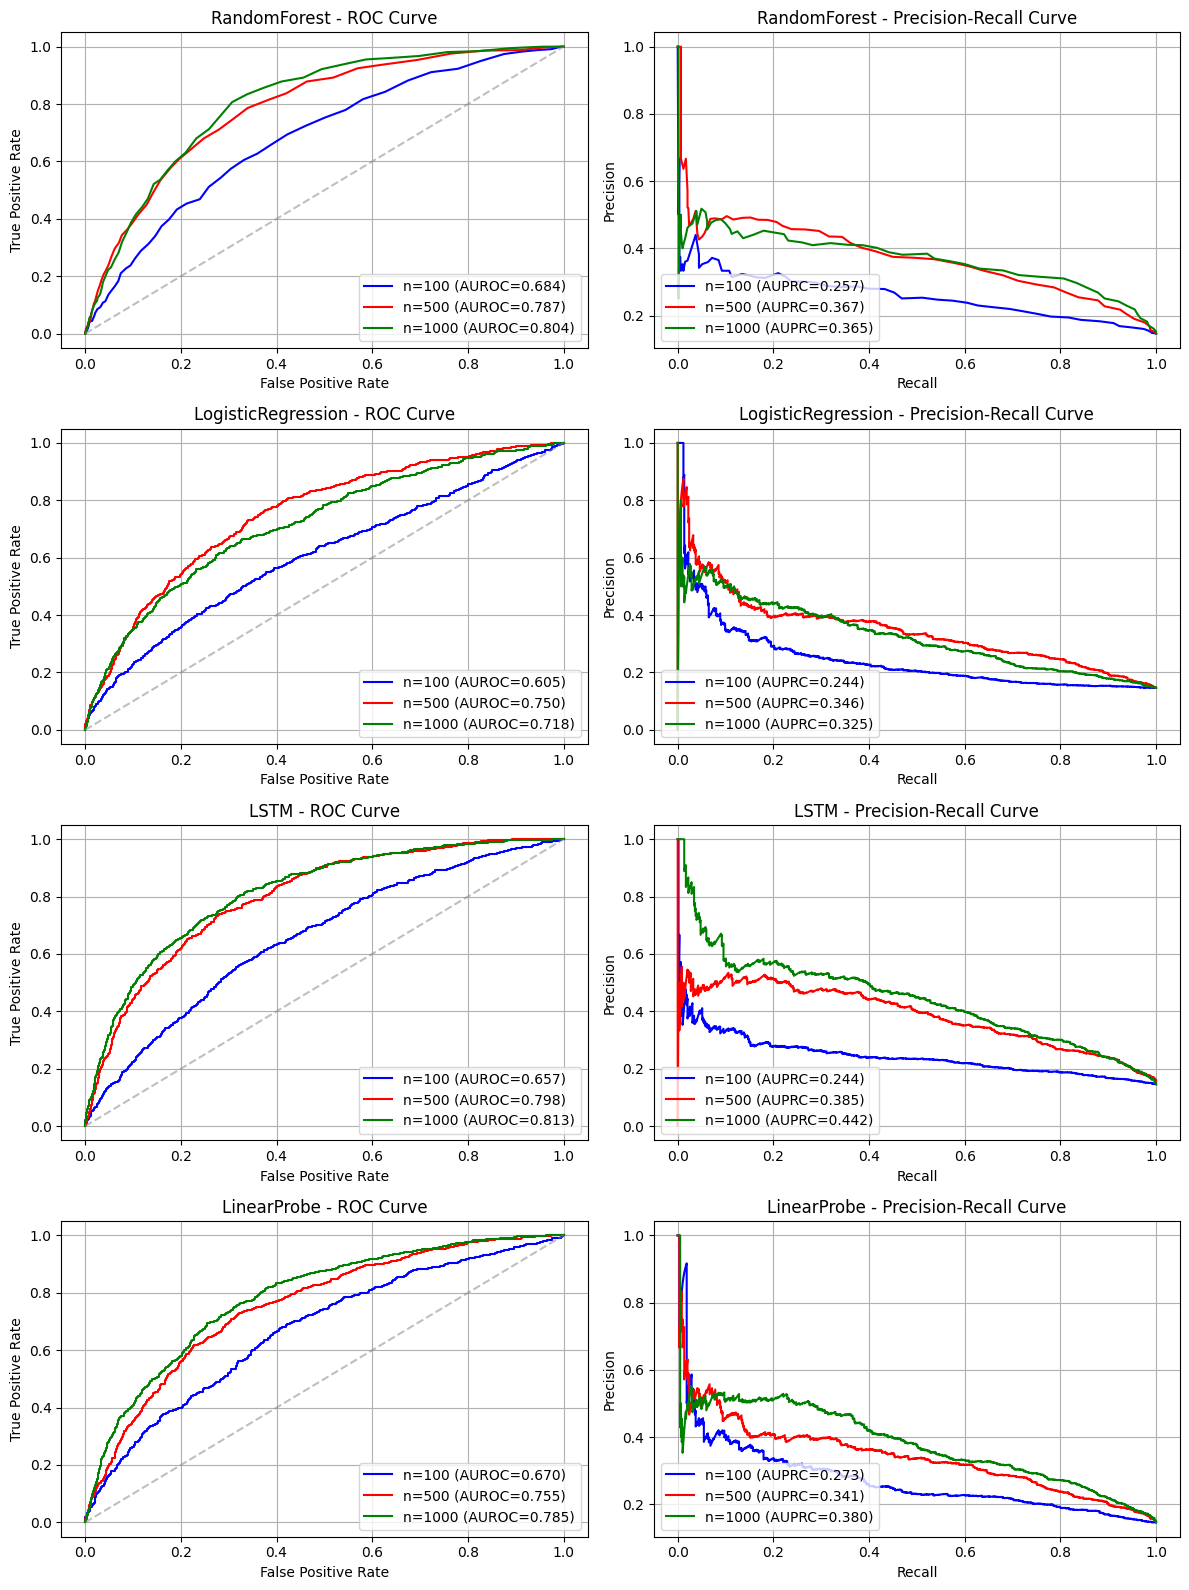

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score, 
    roc_curve, precision_recall_curve
)

# Define colors for different label sizes
label_colors = {100: 'blue', 500: 'red', 1000: 'green', 2000: 'orange'}

# Dictionary to store results for plotting
model_results = {
    "RandomForest": {}, "LogisticRegression": {}, 
    "LSTM": {}, "LinearProbe": {}
}
auroc_scores, auprc_scores = {}, {}

label_sizes = [100, 500, 1000]

print("\n\n--- Supervised Models on Raw Time-series Data ---")
for size in label_sizes:
    idx = np.random.choice(len(X_train), size, replace=False)
    X_train_sub, y_train_sub = X_train[idx], y_train[idx]
    X_val_sub, y_val_sub = X_val[idx], y_val[idx]
    
    
    # Flatten for RF & LogReg
    X_train_flat, X_test_flat = X_train_sub.reshape(size, -1), X_test.reshape(len(X_test), -1)
    
    # 1. Random Forest
    rf_clf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
    rf_clf.fit(X_train_flat, y_train_sub.ravel())
    rf_probs = rf_clf.predict_proba(X_test_flat)[:, 1]
    auroc_scores.setdefault("RandomForest", {})[size] = roc_auc_score(y_test, rf_probs)
    auprc_scores.setdefault("RandomForest", {})[size] = average_precision_score(y_test, rf_probs)
    model_results["RandomForest"][size] = rf_probs

    # 2. Logistic Regression
    lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
    lr_clf.fit(X_train_flat, y_train_sub.ravel())
    lr_probs = lr_clf.predict_proba(X_test_flat)[:, 1]
    auroc_scores.setdefault("LogisticRegression", {})[size] = roc_auc_score(y_test, lr_probs)
    auprc_scores.setdefault("LogisticRegression", {})[size] = average_precision_score(y_test, lr_probs)
    model_results["LogisticRegression"][size] = lr_probs
    
    # 3. LSTM
    lstm_model = tf.keras.Sequential([
        layers.Input(shape=(time_steps, num_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    early_stopping = EarlyStopping(monitor='val_auroc', patience=10, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_auroc', factor=0.5, patience=2, min_lr=1e-6)
    lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss=tf.keras.losses.BinaryCrossentropy(),
                       metrics=["accuracy", tf.keras.metrics.AUC(name="auroc"), 
                                tf.keras.metrics.AUC(name="auprc", curve="PR")])
    
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_sub, y_train_sub)).batch(32)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_sub, y_val_sub)).batch(32)
    
    lstm_model.fit(train_ds, epochs=20, verbose=0, callbacks=[early_stopping, lr_scheduler],validation_data=val_ds)
    lstm_probs = lstm_model.predict(X_test).ravel()
    auroc_scores.setdefault("LSTM", {})[size] = roc_auc_score(y_test, lstm_probs)
    auprc_scores.setdefault("LSTM", {})[size] = average_precision_score(y_test, lstm_probs)
    model_results["LSTM"][size] = lstm_probs

print("\n\n--- Linear Probes on Precomputed Embeddings ---")
for size in label_sizes:
    idx = np.random.choice(len(X_train_embed), size, replace=False)
    X_train_embed_sub = X_train_embed[idx]
    
    probe_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
    probe_clf.fit(X_train_embed_sub, y_train[idx].ravel())

    probe_probs = probe_clf.predict_proba(X_test_embed)[:, 1]
    auroc_scores.setdefault("LinearProbe", {})[size] = roc_auc_score(y_test, probe_probs)
    auprc_scores.setdefault("LinearProbe", {})[size] = average_precision_score(y_test, probe_probs)
    model_results["LinearProbe"][size] = probe_probs

# --- Plot Graphs ---
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for i, model_name in enumerate(["RandomForest", "LogisticRegression", "LSTM", "LinearProbe"]):
    # ROC Curves
    ax = axes[i, 0]
    for size in label_sizes:
        fpr, tpr, _ = roc_curve(y_test, model_results[model_name][size])
        auc_value = auroc_scores[model_name][size]
        ax.plot(fpr, tpr, label=f"n={size} (AUROC={auc_value:.3f})", color=label_colors[size])
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
    ax.set_title(f"{model_name} - ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

    # Precision-Recall Curves
    ax = axes[i, 1]
    for size in label_sizes:
        precision, recall, _ = precision_recall_curve(y_test, model_results[model_name][size])
        auc_value = auprc_scores[model_name][size]
        ax.plot(recall, precision, label=f"n={size} (AUPRC={auc_value:.3f})", color=label_colors[size])
    ax.set_title(f"{model_name} - Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="lower left")
    ax.grid(True)

plt.tight_layout()
plt.show()


# 3.3

In [7]:
import numpy as np
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

# Compute Silhouette Score (higher = better, range [-1, 1])
silhouette = silhouette_score(X_test_embed, y_test.ravel())

# Compute Calinski-Harabasz Index (higher = better)
calinski = calinski_harabasz_score(X_test_embed, y_test.ravel())

# Compute Davies-Bouldin Index (lower = better)
davies_bouldin = davies_bouldin_score(X_test_embed, y_test.ravel())

print(f"Silhouette Score: {silhouette:.3f}")
print(f"Calinski-Harabasz: {calinski:.3f}")
print(f"Davies-Bouldin: {davies_bouldin:.3f}")

Silhouette Score: 0.035
Calinski-Harabasz: 34.663
Davies-Bouldin: 7.630


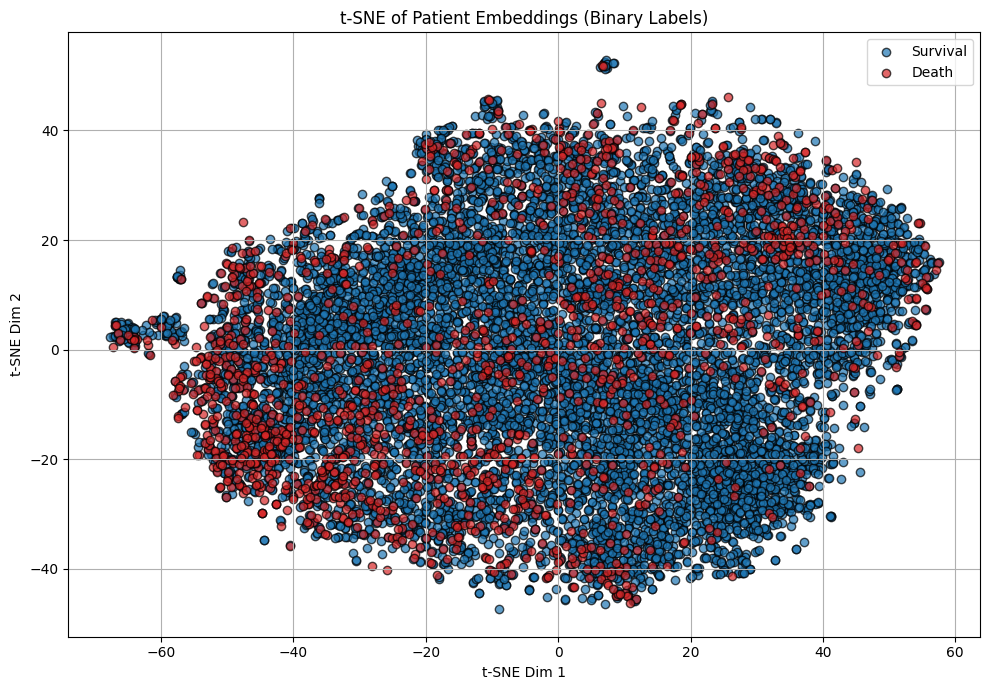

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Combine embeddings and labels
X_all_embed = np.concatenate([X_train_embed, X_val_embed, X_test_embed], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0).ravel()


# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=70)
# X_tsne = tsne.fit_transform(X_test_embed)
X_tsne = tsne.fit_transform(X_all_embed)

# Define distinct colors for binary classes
colors = ['#1f77b4', '#d62728']  # blue and red
labels = ['Survival', 'Death']

plt.figure(figsize=(10, 7))

for class_val in [0, 1]:
    indices = (y_all == class_val)
    plt.scatter(
        X_tsne[indices, 0],  # select first t-SNE component
        X_tsne[indices, 1],  # select second t-SNE component
        c=colors[class_val],
        label=labels[class_val],
        alpha=0.7,
        edgecolors='k'
    )

plt.title('t-SNE of Patient Embeddings (Binary Labels)')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


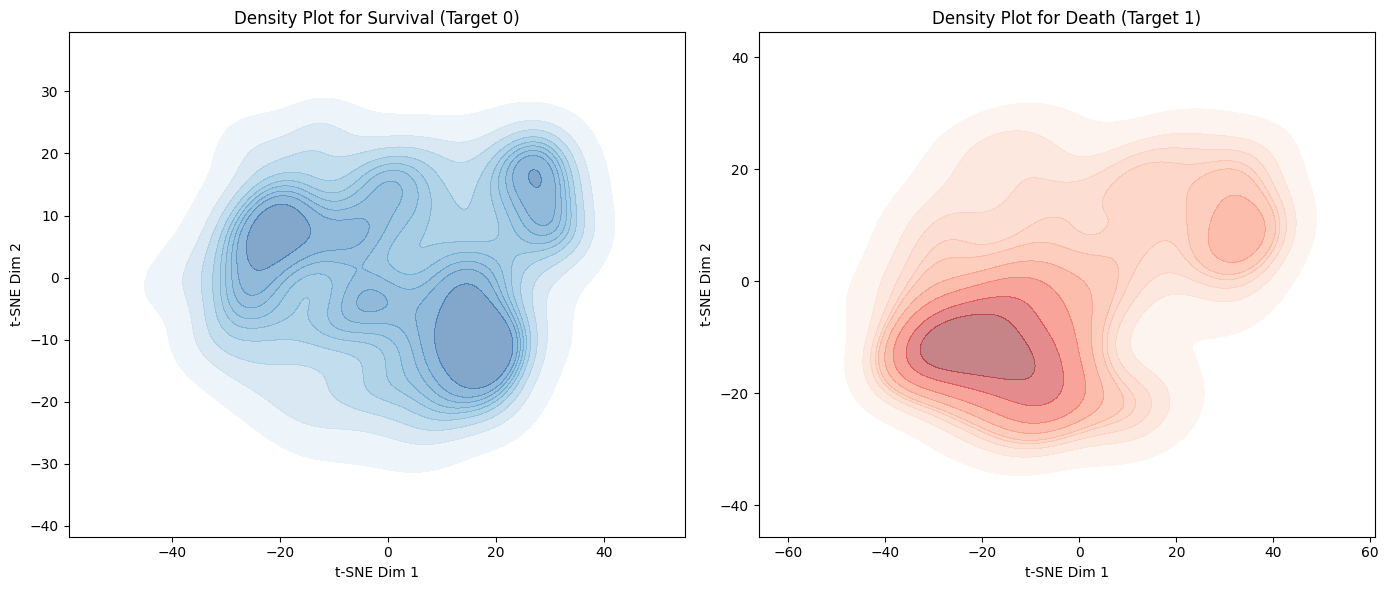

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Combine embeddings and labels
X_all_embed = np.concatenate([X_train_embed, X_val_embed, X_test_embed], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0).ravel()

# Run t-SNE on the combined embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=70)
X_tsne = tsne.fit_transform(X_test_embed)

# Create a DataFrame with the t-SNE coordinates and target labels
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Target': y_test.ravel()
})

# Create a figure with 2 subplots: one for each target class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Density plot for the 'Survival' class (target 0)
sns.kdeplot(
    data=tsne_df[tsne_df['Target'] == 0],
    x='TSNE1', y='TSNE2',
    fill=True,
    cmap="Blues",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Density Plot for Survival (Target 0)")
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")

# Density plot for the 'Death' class (target 1)
sns.kdeplot(
    data=tsne_df[tsne_df['Target'] == 1],
    x='TSNE1', y='TSNE2',
    fill=True,
    cmap="Reds",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Density Plot for Death (Target 1)")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")

plt.tight_layout()
plt.show()


/Users/andras/hcml_projects/ML4H_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/andras/hcml_projects/ML4H_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andras/hcml_projects/ML4H_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


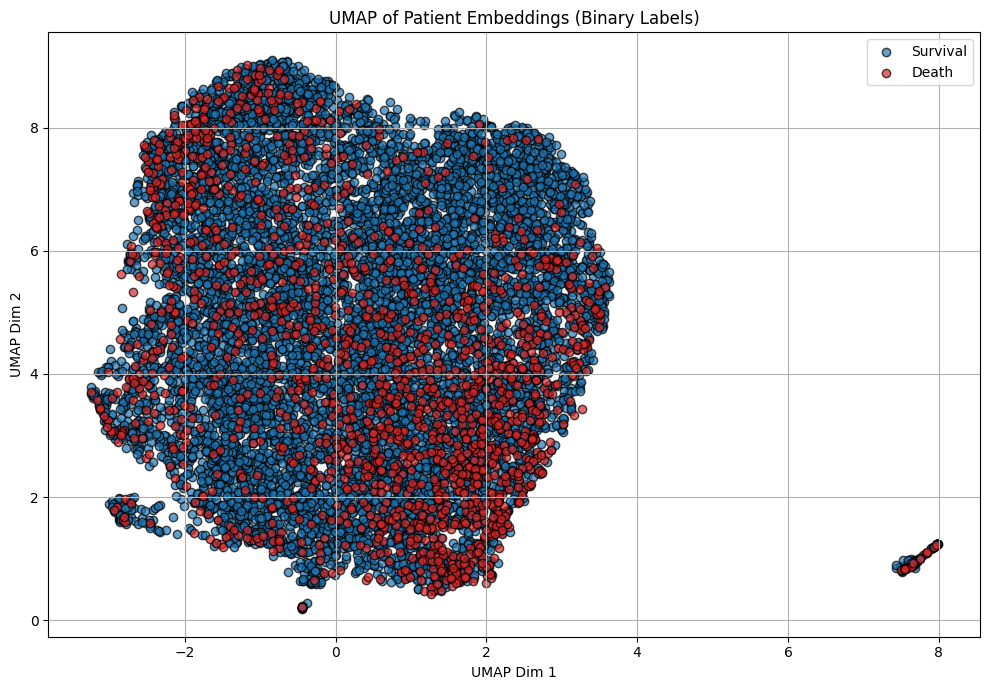

In [10]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np

# Combine embeddings and labels
X_all_embed = np.concatenate([X_train_embed, X_val_embed, X_test_embed], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0).ravel()

# Run UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_all_embed)

# Define distinct colors for binary classes
colors = ['#1f77b4', '#d62728']  # blue for Survival, red for Death
labels_text = ['Survival', 'Death']

plt.figure(figsize=(10, 7))
for class_val in [0, 1]:
    indices = (y_all == class_val)
    plt.scatter(
        X_umap[indices, 0],  # UMAP Dim 1
        X_umap[indices, 1],  # UMAP Dim 2
        c=colors[class_val],
        label=labels_text[class_val],
        alpha=0.7,
        edgecolors='k'
    )

plt.title('UMAP of Patient Embeddings (Binary Labels)')
plt.xlabel('UMAP Dim 1')
plt.ylabel('UMAP Dim 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/Users/andras/hcml_projects/ML4H_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/andras/hcml_projects/ML4H_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


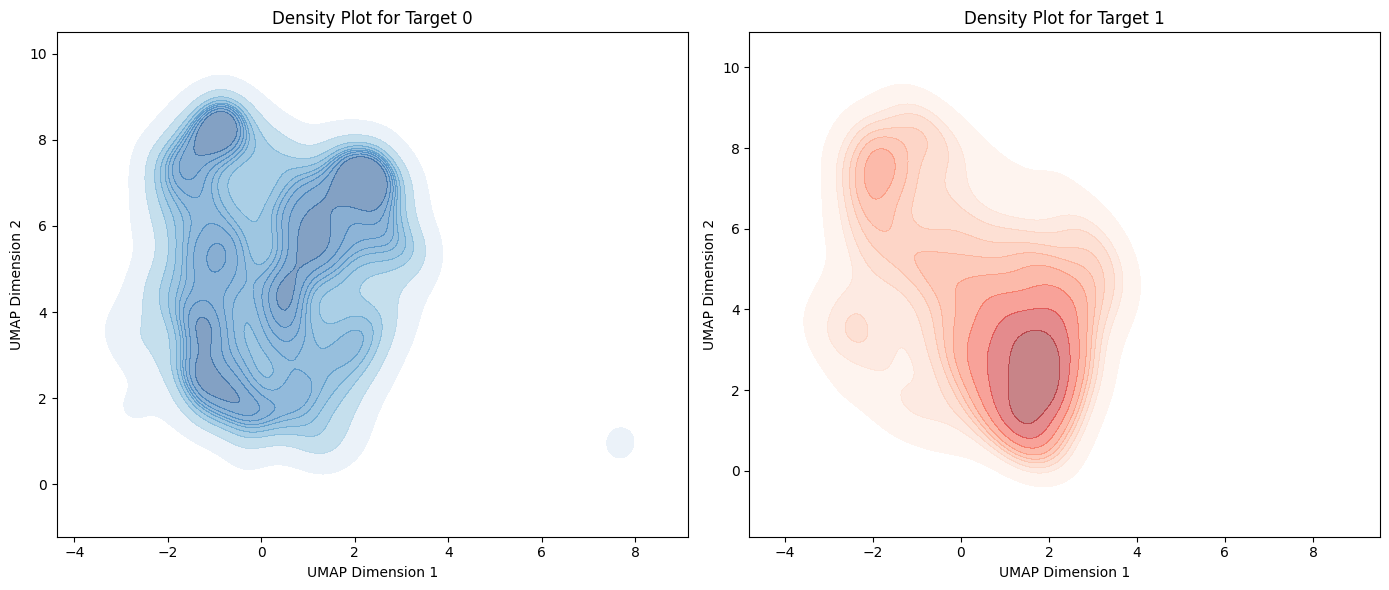

In [11]:
import umap.umap_ as umap 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Concatenate all embeddings and corresponding targets (assuming these are already computed)
all_embeddings = np.concatenate([X_train_embed, X_val_embed, X_test_embed], axis=0)
all_targets = np.concatenate([y_train, y_val, y_test], axis=0).ravel()

# Apply UMAP to reduce embeddings to 2 dimensions
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
all_umap = umap_reducer.fit_transform(all_embeddings)

# Create a DataFrame for easier plotting with Seaborn
umap_df = pd.DataFrame({
    'UMAP1': all_umap[:, 0],
    'UMAP2': all_umap[:, 1],
    'Target': all_targets
})

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot density for Target 0
sns.kdeplot(
    data=umap_df[umap_df['Target'] == 0],
    x='UMAP1', y='UMAP2',
    fill=True,
    cmap="Blues",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Density Plot for Target 0")
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")

# Plot density for Target 1
sns.kdeplot(
    data=umap_df[umap_df['Target'] == 1],
    x='UMAP1', y='UMAP2',
    fill=True,
    cmap="Reds",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Density Plot for Target 1")
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()
